# 14.8 位置插值如何延長窗口？


沿用十六張文字卡片，原模型為八個位置配置了位置刻度。我們想保留整段內容，又希望位置旋轉不要直接一路延到第15格。可以先把座標尺縮小：卡片仍有十六張，第一張的座標是0，第二張變成0.5，第三張變成1，後面繼續每次增加半格。這種在算位置資訊前縮放座標的做法，叫位置插值，英文是Position Interpolation。

八格延到十六格，所以每個原位置都乘上8除以16，也就是除以2。原位置2變成1，位置14變成7，位置15變成7.5。注意最後一張沒有映到7：這個方法用的是八與十六的長度比例，不是強迫兩端的編號完全重合。

原來八格的座標範圍是大於等於0、小於8，訓練真正使用的則是整數0到7。縮放後十六張卡的座標是0到7.5，都沒有到達8；但0.5、7.5等分數座標，不等於原來用過的整數位置。插值的意思正是讓同一個位置函數也在這些新刻度上求值，而不是宣稱模型早已見過每個新刻度。

下圖每張卡保留同一個字。字下第一個數字是原位置，向下箭頭表示除以2，最下面是交給旋轉公式的新座標。0到15的卡片仍各有自己的內容，只是位置刻度更密。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

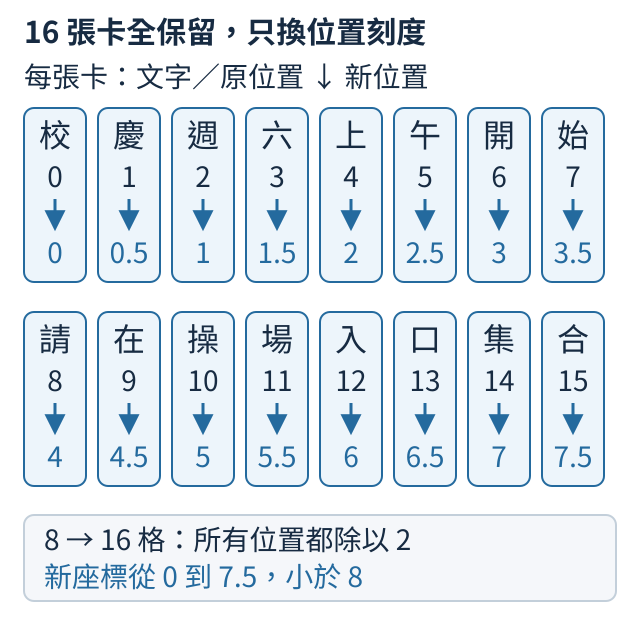

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-14-8-position-interpolation.svg")))

把做法寫成算式，若原長度是L、新長度是L′、卡片原位置是m，新座標便是`m × L / L′`。這三個字母只是本次長度與位置的名字；在例子裡L是8、L′是16。接著用這個新座標計算RoPE的轉角，例如某組每格轉60度，原位置2本來轉120度，插值後以座標1計算，便轉60度。被縮放的是位置帶來的轉角，卡片內容沒有被刪除或合併。

可以用下面幾行Python核對座標。`range(16)`列出0到15，第三行把每個位置按同一比例換算；這段只計算位置座標。


In [3]:
L, L_prime = 8, 16
positions = list(range(L_prime))
coordinates = [m * L / L_prime for m in positions]
print("卡片數", len(positions), "座標數", len(coordinates))
for m in (0, 1, 2, 14, 15):
    print(m, "→", coordinates[m])

卡片數 16 座標數 16
0 → 0.0
1 → 0.5
2 → 1.0
14 → 7.0
15 → 7.5


第一行輸出應顯示卡片數與座標數都是16。接著五組對應是0到0.0、1到0.5、2到1.0、14到7.0、15到7.5。兩個數量相同，提醒我們每張卡仍有一個位置座標；不能把座標7當成只剩八張卡的證據。

這樣做讓原本相隔十五格的位置，在旋轉公式裡相隔7.5格，減少直接超出原座標範圍的部分。可是鄰近位置的角度也一起改變了，既有權重未必立刻會使用這種新刻度。實際延長模型時，通常要用縮放後的較長片段繼續訓練，讓權重適應，再同時驗收較長任務與原本的短任務。

練習把`L_prime`改成24，保留L為8，再把`for`要列印的位置改成`(5, 23)`。先預測位置5與最後位置23會映到哪裡，再執行核對。此時每個位置除以3，所以得到約1.6667與7.6667；二十四張卡仍有二十四個座標。下一節要看「全部除以同一個數」會如何改變鄰近兩張卡的旋轉差。

<details>
<summary>權威來源與方法條件</summary>

位置變換依[Position Interpolation，arXiv:2306.15595v2，§2.3式4](https://arxiv.org/pdf/2306.15595v2)；微調、長序列語言建模、取回線索與原窗口能力的檢查見§3.1–3.4。論文支持位置插值配合其訓練與評測設定延長窗口，沒有保證任意模型只改一個設定便能保持品質。更多查證在[來源筆記](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-revision-20261005/sources/context.md)。本節只核對座標算式。

</details>
